In [1]:
import numpy as np
from numpy.linalg import lstsq

def cp_als_2d(X, rank, n_iter=50, tol=1e-6):
    """
    CP decomposition for 2D matrices using ALS.
    
    Args:
        X: 2D numpy array (m x n), the input matrix (e.g., function values on a grid)
        rank: target CP rank
        n_iter: max number of ALS iterations
        tol: convergence tolerance
    
    Returns:
        A (m x rank), B (n x rank) such that X ≈ A @ B.T
    """
    m, n = X.shape
    A = np.random.randn(m, rank)
    B = np.random.randn(n, rank)

    X_T = X.T

    for i in range(n_iter):
        A_old, B_old = A.copy(), B.copy()

        # Update A (solving: X = A @ B.T -> A = X @ B @ (B.T @ B)^(-1))
        BtB = B.T @ B
        A = X @ B @ np.linalg.pinv(BtB)

        # Update B (solving: X.T = B @ A.T -> B = X.T @ A @ (A.T @ A)^(-1))
        AtA = A.T @ A
        B = X_T @ A @ np.linalg.pinv(AtA)

        # Check for convergence
        err = np.linalg.norm(X - A @ B.T) / np.linalg.norm(X)
        if err < tol:
            print(f"Converged at iteration {i}, rel error: {err:.2e}")
            break

    return A, B

# Example usage
if __name__ == "__main__":
    # Create a low-rank test function: f(x,y) = sum_i a_i(x) * b_i(y)
    N = 64
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    Xg, Yg = np.meshgrid(x, y, indexing='ij')
    f = lambda x, y: np.exp(-5 * (x**2 + y**2))
    X = f(Xg, Yg)

    rank = 1
    A, B = cp_als_2d(X, rank)

    # Reconstructed matrix
    X_hat = A @ B.T
    print("RMSE:", np.sqrt(np.mean((X - X_hat)**2)))


Converged at iteration 0, rel error: 1.84e-16
RMSE: 5.0880663039490576e-17


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:28: RuntimeWarning: divide by zero encountered in matmul
  A = X @ B @ np.linalg.pinv(BtB)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:28: RuntimeWarning: overflow encountered in matmul
  A = X @ B @ np.linalg.pinv(BtB)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:28: RuntimeWarning: invalid value encountered in matmul
  A = X @ B @ np.linalg.pinv(BtB)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:32: RuntimeWarning: divide by zero encountered in matmul
  B = X_T @ A @ np.linalg.pinv(AtA)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:32: RuntimeWarning: overflow encountered in matmul
  B = X_T @ A @ np.linalg.pinv(AtA)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1631951049.py:32: RuntimeWarning: invalid value encountered in matmul
  B = X_T @ A @ np.linal

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1463031025.py:41: RuntimeWarning: divide by zero encountered in matmul
  err = np.linalg.norm(f_vals - A @ B.T) / np.linalg.norm(f_vals)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1463031025.py:41: RuntimeWarning: overflow encountered in matmul
  err = np.linalg.norm(f_vals - A @ B.T) / np.linalg.norm(f_vals)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1463031025.py:41: RuntimeWarning: invalid value encountered in matmul
  err = np.linalg.norm(f_vals - A @ B.T) / np.linalg.norm(f_vals)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1463031025.py:63: RuntimeWarning: divide by zero encountered in matmul
  Xhat = np.tensordot(Tx @ A, Ty @ B, axes=([1], [1]))
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42345/1463031025.py:63: RuntimeWarning: overflow encountered in matmul
  Xhat = np.tensordot(Tx @ A, Ty @ B, axes=([1], [1]))
/var/folders/8c/zb8gstqn6

Converged at iteration 0, rel error: 3.67e-16


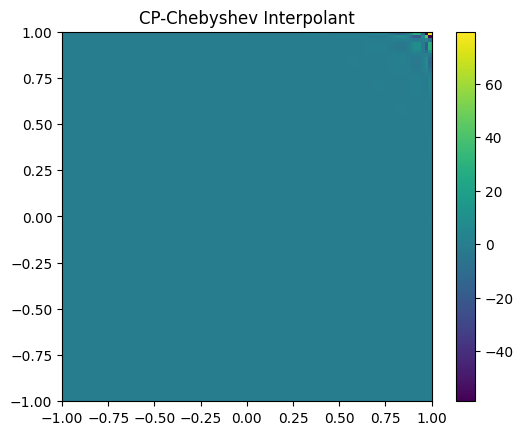

In [2]:
import numpy as np
from numpy.polynomial.chebyshev import chebval
from numpy.linalg import pinv

def chebyshev_nodes(n):
    k = np.arange(n)
    return np.cos((2*k + 1) * np.pi / (2*n))

def chebyshev_polys(x, deg):
    T = np.zeros((len(x), deg+1))
    T[:, 0] = 1
    if deg >= 1:
        T[:, 1] = x
    for k in range(2, deg+1):
        T[:, k] = 2 * x * T[:, k-1] - T[:, k-2]
    return T

def cp_chebyshev_fit_2d(f_vals, rank, n_iter=50, tol=1e-6):
    """
    Fit CP-decomposed Chebyshev interpolant for 2D function.

    Args:
        f_vals: (N+1, N+1) array, function values at Chebyshev nodes
        rank: target CP rank
        n_iter: ALS iterations
        tol: tolerance

    Returns:
        A, B: CP-decomposed coefficient matrix, such that C ≈ A @ B.T
    """
    Np1 = f_vals.shape[0]
    A = np.random.randn(Np1, rank)
    B = np.random.randn(Np1, rank)

    for i in range(n_iter):
        B_pinv = pinv(B.T @ B)
        A = f_vals @ B @ B_pinv
        A_pinv = pinv(A.T @ A)
        B = f_vals.T @ A @ A_pinv

        err = np.linalg.norm(f_vals - A @ B.T) / np.linalg.norm(f_vals)
        if err < tol:
            print(f"Converged at iteration {i}, rel error: {err:.2e}")
            break

    return A, B

def evaluate_cp_chebyshev_interp_2d(A, B, x_eval, y_eval):
    """
    Evaluate CP Chebyshev interpolant on new grid.

    Args:
        A, B: CP rank-1 factors for coefficients
        x_eval, y_eval: 1D arrays for evaluation

    Returns:
        F_hat: interpolated values on meshgrid
    """
    deg = A.shape[0] - 1
    Tx = chebyshev_polys(x_eval, deg)  # shape: (len(x), deg+1)
    Ty = chebyshev_polys(y_eval, deg)

    Xhat = np.tensordot(Tx @ A, Ty @ B, axes=([1], [1]))
    return Xhat

# Example usage
if __name__ == "__main__":
    N = 32
    x_nodes = chebyshev_nodes(N+1)
    y_nodes = chebyshev_nodes(N+1)
    Xg, Yg = np.meshgrid(x_nodes, y_nodes, indexing='ij')
    f = lambda x, y: np.exp(-5*(x**2 + y**2))
    F = f(Xg, Yg)

    rank = 5
    A, B = cp_chebyshev_fit_2d(F, rank)

    # Evaluate on finer grid
    x_eval = np.linspace(-1, 1, 100)
    y_eval = np.linspace(-1, 1, 100)
    F_interp = evaluate_cp_chebyshev_interp_2d(A, B, x_eval, y_eval)

    import matplotlib.pyplot as plt
    plt.imshow(F_interp, extent=(-1, 1, -1, 1), origin='lower')
    plt.title("CP-Chebyshev Interpolant")
    plt.colorbar()
    plt.show()


In [3]:
import numpy as np
from numpy.polynomial.chebyshev import chebfit, chebval
from numpy.linalg import pinv

def chebyshev_nodes(n):
    k = np.arange(n)
    return np.cos((2*k + 1) * np.pi / (2*n))

def cp_decompose(C, rank, n_iter=50, tol=1e-6):
    """CP decomposition of coefficient matrix C ≈ A @ B.T"""
    n = C.shape[0]
    A = np.random.randn(n, rank)
    B = np.random.randn(n, rank)

    for i in range(n_iter):
        A_old = A.copy()
        B_old = B.copy()

        B_pinv = pinv(B.T @ B)
        A = C @ B @ B_pinv

        A_pinv = pinv(A.T @ A)
        B = C.T @ A @ A_pinv

        err = np.linalg.norm(C - A @ B.T) / np.linalg.norm(C)
        if err < tol:
            print(f"Converged at iter {i}, rel error = {err:.2e}")
            break
    return A, B

def evaluate_cp_cheb_interp(A, B, x_eval, y_eval):
    """Evaluate interpolant from CP-decomposed Chebyshev coefficients"""
    deg = A.shape[0] - 1
    Tx = np.polynomial.chebyshev.chebvander(x_eval, deg)  # (len(x_eval), deg+1)
    Ty = np.polynomial.chebyshev.chebvander(y_eval, deg)

    return (Tx @ A) @ (Ty @ B).T  # Outer product sum

# --- Example usage ---
if __name__ == "__main__":
    N = 32
    x_nodes = chebyshev_nodes(N+1)
    y_nodes = chebyshev_nodes(N+1)
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

    f = lambda x, y: np.exp(-5*(x**2 + y**2))
    F = f(X, Y)

    # Step 1: Compute full Chebyshev coefficients
    coeffs = np.polynomial.chebyshev.chebfit2d(x_nodes, y_nodes, F, [N, N])

    # Step 2: CP decompose the coefficient matrix
    rank = 5
    A, B = cp_decompose(coeffs, rank)

    # Step 3: Evaluate interpolant from CP-decomposed coefficients
    x_eval = np.linspace(-1, 1, 100)
    y_eval = np.linspace(-1, 1, 100)
    F_interp = evaluate_cp_cheb_interp(A, B, x_eval, y_eval)

    # Plot
    import matplotlib.pyplot as plt
    plt.imshow(F_interp, extent=(-1, 1, -1, 1), origin='lower')
    plt.title("Direct Chebyshev Interpolation via CP")
    plt.colorbar()
    plt.show()


AttributeError: module 'numpy.polynomial.chebyshev' has no attribute 'chebfit2d'

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:20: RuntimeWarning: divide by zero encountered in matmul
  err = np.linalg.norm(C - A @ B.T) / np.linalg.norm(C)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:20: RuntimeWarning: overflow encountered in matmul
  err = np.linalg.norm(C - A @ B.T) / np.linalg.norm(C)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:20: RuntimeWarning: invalid value encountered in matmul
  err = np.linalg.norm(C - A @ B.T) / np.linalg.norm(C)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:30: RuntimeWarning: divide by zero encountered in matmul
  return (Tx @ A) @ (Ty @ B).T
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:30: RuntimeWarning: overflow encountered in matmul
  return (Tx @ A) @ (Ty @ B).T
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_6864/1282153314.py:30: RuntimeWarning: invalid va

Converged at iteration 0, rel error = 1.16e-15


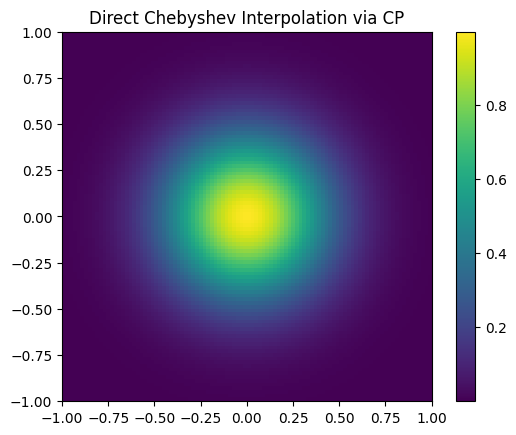

In [ ]:
import numpy as np
from numpy.polynomial.chebyshev import chebfit, chebvander
from numpy.linalg import pinv

def chebyshev_nodes(n):
    k = np.arange(n)
    return np.cos((2*k + 1) * np.pi / (2*n))

def cp_decompose(C, rank, n_iter=50, tol=1e-6):
    n = C.shape[0]
    A = np.random.randn(n, rank)
    B = np.random.randn(n, rank)

    for i in range(n_iter):
        B_pinv = pinv(B.T @ B)
        A = C @ B @ B_pinv
        A_pinv = pinv(A.T @ A)
        B = C.T @ A @ A_pinv

        err = np.linalg.norm(C - A @ B.T) / np.linalg.norm(C)
        if err < tol:
            print(f"Converged at iteration {i}, rel error = {err:.2e}")
            break
    return A, B

def evaluate_cp_cheb_interp(A, B, x_eval, y_eval):
    deg = A.shape[0] - 1
    Tx = chebvander(x_eval, deg)
    Ty = chebvander(y_eval, deg)
    return (Tx @ A) @ (Ty @ B).T

# --- Example usage ---
if __name__ == "__main__":
    N = 32
    x_nodes = chebyshev_nodes(N+1)
    y_nodes = chebyshev_nodes(N+1)
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

    f = lambda x, y: np.exp(-5*(x**2 + y**2))
    F = f(X, Y)

    # Step 1: Manual 2D Chebyshev coefficient computation
    coeffs = np.zeros((N+1, N+1))
    for j in range(N+1):
        coeffs[:, j] = chebfit(x_nodes, F[:, j], N)
    for i in range(N+1):
        coeffs[i, :] = chebfit(y_nodes, coeffs[i, :], N)

    # Step 2: CP Decomposition of coefficient matrix
    rank = 5
    A, B = cp_decompose(coeffs, rank)

    # Step 3: Evaluate
    x_eval = np.linspace(-1, 1, 100)
    y_eval = np.linspace(-1, 1, 100)
    F_interp = evaluate_cp_cheb_interp(A, B, x_eval, y_eval)

    # Plot
    import matplotlib.pyplot as plt
    plt.imshow(F_interp, extent=(-1, 1, -1, 1), origin='lower')
    plt.title("Direct Chebyshev Interpolation via CP")
    plt.colorbar()
    plt.show()
